# Practice 2: Tree-based model for classification

**DS-GA 3001 Visualization for Machine Learning — Week 4 Lab (Sept 29, 2026)**

A decision tree is a white-box model in the most literal sense: you can draw the whole thing and
read the rules out loud. This notebook shows what that buys you, and what happens when the tree
grows too large to read.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The dataset we are using in this lab comes from the FICO xAI challenge:
https://community.fico.com/s/explainable-machine-learning-challenge

Each row is a home equity line of credit application. `Outcome` is 1 if the applicant was
90 days late on a payment within two years, and the other 23 columns are credit bureau features.

The cleaned copy is read straight from the shared link, so there is nothing to download and no
Google Drive to mount:
https://drive.google.com/file/d/186LjbAZoMat91ByH7aJGJ8PnfO2LqKlu/view?usp=sharing

In [2]:
FICO_URL = "https://drive.google.com/uc?export=download&id=186LjbAZoMat91ByH7aJGJ8PnfO2LqKlu"

df = pd.read_csv(FICO_URL)
df

,Outcome,External Risk Estimate,Months Since Oldest Trade Open,Months Since Last Trade Open,Average Months in File,Satisfactory Trades,Trades 60+ Ever,Trades 90+ Ever,Bills Paid on Time,Months Since Last Delq.,...,% Installment Trades,Months Since Most Recent Inq,Inq Last 6 Months,Inq Last 6 Months exl. 7 days,Unpaid Balance,Installment Burden,Revolving Trades w/ Balance,Installment Trades w/ Balance,Bank Trades w/ High Utilization Ratio,% Trades w/ Balance
0,0,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,77,8,1,1,69
1,0,61,58,15,41,2,4,4,100,150,...,67,0,0,0,0,57,0,2,0,0
2,0,67,66,5,24,9,0,0,100,150,...,44,0,4,4,53,66,4,2,1,86
3,0,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,0,81,333,27,132,12,0,0,100,150,...,25,0,1,1,51,89,3,1,0,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,1,73,131,5,57,21,0,0,95,80,...,19,7,0,0,26,81,5,2,0,100
9867,0,65,147,39,68,11,0,0,92,28,...,42,1,1,1,86,53,2,2,1,80
9868,0,74,129,6,64,18,1,1,100,150,...,33,3,4,4,6,53,5,3,0,56
9869,0,72,234,12,113,42,2,2,96,35,...,20,6,0,0,19,47,4,1,0,38


In [3]:
print("shape:", df.shape)
df['Outcome'].value_counts(normalize=True).rename("class balance")

shape: (9871, 24)


Outcome
0    0.520312
1    0.479688
Name: class balance, dtype: float64

The two classes are close to balanced, so plain accuracy is a reasonable summary here. That is not
usually true, as the disease-prediction example in last week's lecture showed.

In [4]:
X = df.drop(columns=['Outcome']).values
y = df['Outcome'].values

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [6]:
'''train a decision tree model'''
from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

In [7]:
'''report the training accuracy'''
clf.score(X_train, y_train)

1.0

In [8]:
'''report the testing accuracy'''
clf.score(X_test, y_test)

0.6212400245549416

In [9]:
'''how big did it get?'''
print(f"depth {clf.get_depth()}, leaves {clf.get_n_leaves()}")

depth 30, leaves 1212


Perfect on the data it was fitted to, barely better than a coin flip on data it has not seen. The
tree has memorised the training set: with hundreds of leaves there is roughly one leaf per handful
of applicants.

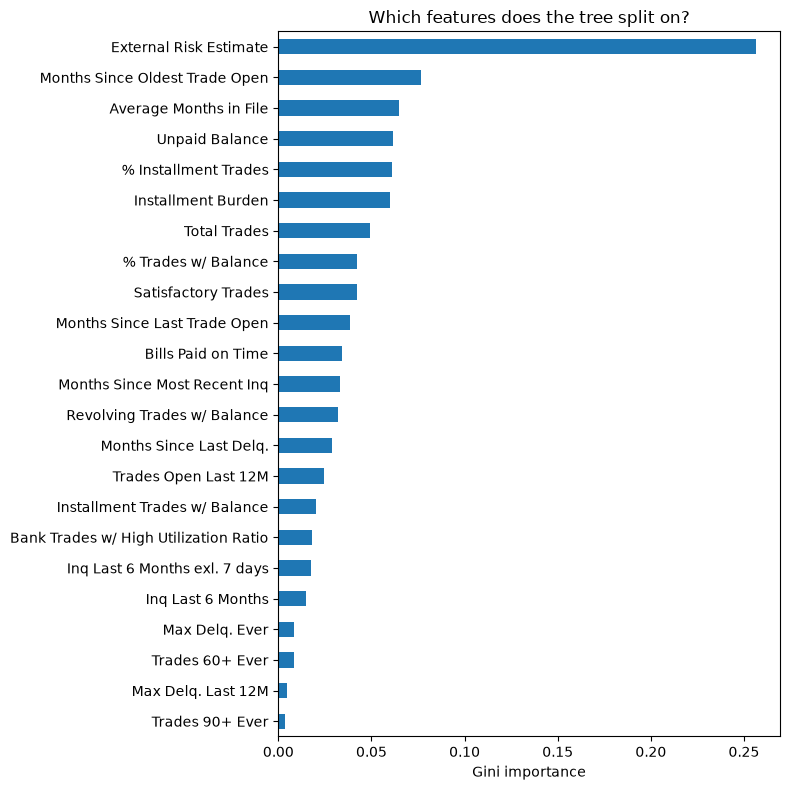

In [10]:
'''feature importance, as a chart rather than 23 bare numbers'''
importances = pd.Series(clf.feature_importances_, index=df.columns[1:]).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot.barh(ax=ax)
ax.set_xlabel("Gini importance")
ax.set_title("Which features does the tree split on?")
plt.tight_layout()
plt.show()

In [11]:
'''visualize the tree'''
import graphviz

target_names = ['not default', 'default']
dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=df.columns[1:],
                                class_names=target_names,
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

A really large tree!!!

Overfiting!!

The picture is honest and completely useless: a model you cannot read is not an interpretable
model, whatever its type. Check the parameters you can change:
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [12]:
'''
  Change parameters to avoid overfitting.
'''

clf = tree.DecisionTreeClassifier(min_samples_split=50, max_depth=5)
clf = clf.fit(X_train, y_train)

In [13]:
print(f"train {clf.score(X_train, y_train):.4f}   test {clf.score(X_test, y_test):.4f}")
print(f"depth {clf.get_depth()}, leaves {clf.get_n_leaves()}")

train 0.7388   test 0.6961
depth 5, leaves 31


Worse on the training set, **better on the test set**, and small enough to look at. That trade is
the whole lesson.

### Now draw it again

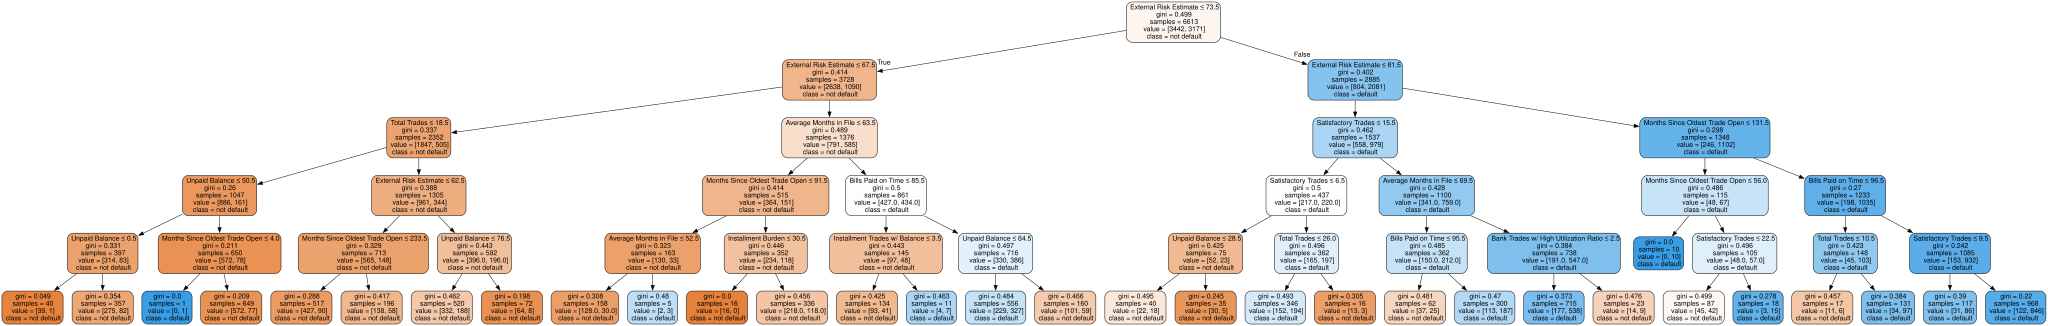

In [14]:
dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=df.columns[1:],
                                class_names=target_names,
                                filled=True, rounded=True,
                                special_characters=True)
graphviz.Source(dot_data)

This is what a white-box model is supposed to look like. Follow any path from the root to a leaf
and you have a sentence: *if the external risk estimate is below this and the file is younger than
that, the model predicts default.*

In [15]:
'''the same tree as rules you can read aloud (top levels only)'''
from sklearn.tree import export_text

print(export_text(clf, feature_names=list(df.columns[1:]), max_depth=2))

|--- External Risk Estimate <= 73.50
|   |--- External Risk Estimate <= 67.50
|   |   |--- Total Trades <= 18.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- Total Trades >  18.50
|   |   |   |--- truncated branch of depth 3
|   |--- External Risk Estimate >  67.50
|   |   |--- Average Months in File <= 63.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- Average Months in File >  63.50
|   |   |   |--- truncated branch of depth 3
|--- External Risk Estimate >  73.50
|   |--- External Risk Estimate <= 81.50
|   |   |--- Satisfactory Trades <= 15.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- Satisfactory Trades >  15.50
|   |   |   |--- truncated branch of depth 3
|   |--- External Risk Estimate >  81.50
|   |   |--- Months Since Oldest Trade Open <= 131.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- Months Since Oldest Trade Open >  131.50
|   |   |   |--- truncated branch of depth 3



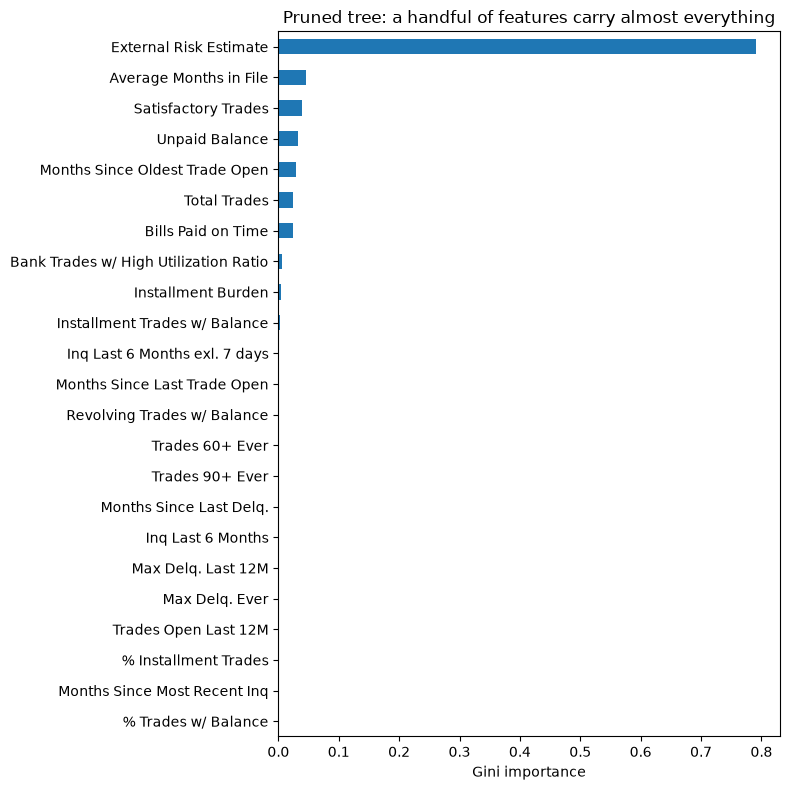

In [16]:
'''and its feature importances - compare with the chart for the overfitted tree above'''
importances = pd.Series(clf.feature_importances_, index=df.columns[1:]).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot.barh(ax=ax)
ax.set_xlabel("Gini importance")
ax.set_title("Pruned tree: a handful of features carry almost everything")
plt.tight_layout()
plt.show()

### Your turn

1. Can you change the parameters and reach a higher test accuracy? Try `max_depth`,
   `min_samples_leaf` and `ccp_alpha`. Report **test** accuracy, not training accuracy.

2. Watch the feature importance chart as you change the depth. Which features appear and disappear?
   What does that instability say about reading importances as an explanation?

3. One feature dominates both charts. Refit the tree without it. How much accuracy do you lose, and
   is the resulting tree a better or a worse explanation of the decision?

In [17]:
# your code here